In [ ]:
import glob
import tqdm
import re

import pandas as pd
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams

from utils import *

EXPERIMENT_RESULTS_PATH = '../Paper-IS26-experiments/'
TYPE_OF_METRICS = 'bootstrapped_metrics-n_1000-stratified' # 'metrics'

rcParams.update({
    "font.size":        16,        
    "axes.titlesize":   16,
    "axes.labelsize":   16,
    "xtick.labelsize":  16,
    "ytick.labelsize":  16,
    "legend.fontsize":  16,
    "figure.titlesize": 16,
})

colors = {
    'ORIGINAL': '#4682B4',          
    'CHALLENGE': "#7BCD5A",            
    'DENOISED': '#87CEEB', 
}

In [263]:
def get_amount_samples(experiment_path):
    splits_path = None
    for path in Path(experiment_path).parents:
        if len(list(path.glob('splits-tvt-*.pkl'))) > 0:
            splits_path = list(path.glob('splits-tvt-*.pkl'))[0]
            break
    if not splits_path:
        return 0
    splits = pd.read_pickle(splits_path)
    acum_test = []
    for r in splits[0]:
        acum_test.extend(r[1])
    acum_train = []
    for r in splits[0]:
        acum_train.extend(r[0])
    assert len(set(acum_train)) == len(set(acum_test)), "Train and test samples are not disjoint"
    return len(set(acum_test))    

In [264]:
results = []
config_columns = []
for experiment_path in tqdm.tqdm(glob.glob(f'{EXPERIMENT_RESULTS_PATH}/**/{TYPE_OF_METRICS}.pkl', recursive=True)):
    amount_samples = get_amount_samples(experiment_path)
    if amount_samples == 0:
        print(f"Could not find splits file for experiment: {experiment_path}. Skipping...")
        continue
    df = pd.read_pickle(experiment_path)
    experiment_config = read_config_from_path(experiment_path, EXPERIMENT_RESULTS_PATH)
    for column, value in experiment_config.items():
        df[column] = value
    df['amount_samples'] = amount_samples
    results.append(df)
    config_columns.extend(experiment_config.keys())

if len(results) == 0:
    raise Warning(f"No results found in the specified path: {EXPERIMENT_RESULTS_PATH}")

results = pd.concat(results, ignore_index=True)
config_columns = list(set(config_columns))
for c in set(config_columns):
    if c:
        results[c] = results[c].fillna('')

results['config'] = results[config_columns].apply(lambda row: '\n'.join([str(c) for c in row if c]), axis=1)

100%|██████████| 96/96 [00:00<00:00, 538.28it/s]


In [265]:
results['feature_label'] = results['feature'].str.split('-').str[0].str.upper().str.replace('MELSPECTROGRAM', 'MELSPECT')

results['subset'] = results['subset'].astype(str)
results['subset'] = results['subset'].str.replace('_balanced', '')
results['subset'] = results['subset'].str.replace('denoised-original', 'denoised')
results['subset'] = results['subset'].str.upper()


In [ ]:
def define_label(row):
  name = ''
  
  if 'full_audio' in row.aligner:
    name += 'Full Audio'
  elif 'non_speech' in row.aligner:
    name += 'Non-Speech'
  else:
    name += 'Speech'
  
  if 'manual' in row.aligner: 
    name += '\nManual'
  elif 'silero' in row.aligner and '0.2' in row.aligner: 
    name += '\nSilero'
  elif 'pyannote' in row.aligner:
    name += '\nPyannote'    
  
  if 'adresso' in row.dataset and 'dataset_audio' in row.aligner:
    name += '-CHALL'
  elif 'spanishad' in row.dataset and 'dataset_11025_16000' in row.aligner:
    name += '-ORIG'
  elif 'denoised' in row.aligner:
    name += '-DENOISED'
  

  if 'concatSegs' in row.feature:
    size = re.search(r"segSize_(\d+(?:\.\d+)?)", row['feature'])
    if size:
      name += f'\n[{size.group(1)}s-chunks]'
    else:
      name += '\n[Concat]'
  if 'concatAudioSegs' in row.feature:
    name += '\n[concatAudioSegs]'
  
  if 'filter' in row.keys() and row['filter'] != '' :
    if 'silero_with_speech_and_wo_10s_non_speech' == row['filter']:
      name += '\n[woSpeech&dur>10s]'
    elif 'silero_with_speech_challenge' == row['filter']:
      name += '\n[Subset]'
    else:
      name += f'\n[{row["filter"].split("_")[-1]}-woSpeech]'
      
  return name


In [267]:
results['label'] = ''
for config, df in results.groupby('config'):
    label = define_label(df.iloc[0])
    results.loc[df.index, 'label'] = label

results.label.unique()

array(['Non-Speech\nSilero\n[5s-chunks]',
       'Non-Speech\nPyannote\n[5s-chunks]',
       'Non-Speech\nManual\n[5s-chunks]', 'Full Audio\n[30s-chunks]',
       'Speech\nManual', 'Non-Speech\nSilero\n[Concat]',
       'Non-Speech\nPyannote\n[Concat]',
       'Non-Speech\nSilero-CHALL\n[5s-chunks]',
       'Non-Speech\nSilero-CHALL\n[Concat]', 'Speech\nSilero',
       'Non-Speech\nSilero-CHALL\n[5s-chunks]\n[Subset]',
       'Non-Speech\nSilero-CHALL\n[Concat]\n[Subset]'], dtype=object)

In [268]:
results.groupby(['config', 'dataset', 'subset', 'feature_label', 'label']).size().reset_index().sort_values('dataset').head()

,config,dataset,subset,feature_label,label,0
47,AcousticCNNClassifier-group_column_subject-wra...,adresso,ORIGINAL,MFCC,Speech\nSilero,10000
61,Wav2Vec2Classifier-group_column_subject-wrap_l...,adresso,DENOISED,WAV2VEC,Non-Speech\nSilero-CHALL\n[Concat],10000
60,Wav2Vec2Classifier-group_column_subject-wrap_l...,adresso,DENOISED,WAV2VEC,Non-Speech\nPyannote\n[Concat],10000
59,Wav2Vec2Classifier-group_column_subject-wrap_l...,adresso,CHALLENGE,WAV2VEC,Non-Speech\nSilero\n[5s-chunks],10000
58,Wav2Vec2Classifier-group_column_subject-wrap_l...,adresso,CHALLENGE,WAV2VEC,Non-Speech\nSilero-CHALL\n[5s-chunks],10000


In [269]:
def get_experiments_to_plot(results, configs):
    df_to_plot, all_label_order = [], []
    for (conditions, label_order) in configs:
        all_label_order.extend(label_order)
        subset = results.copy()
        for col, values in conditions.items():
            if col in subset.columns:
                subset = subset[subset[col].isin(values)]
        if subset.empty: continue
        df_to_plot.append(subset)
    df_to_plot = pd.concat(df_to_plot, ignore_index=True)
    return df_to_plot, all_label_order



def plot_experiments_of_dataset(axes, df_to_plot, all_label_order, feature_order, subset_order, metric, bar_w, sep=3.5):
    axes = [axes] if len(feature_order) == 1 else axes.flatten()
    for ax, feature in zip(axes, feature_order):
        feature_df = df_to_plot[df_to_plot["feature_label"] == feature]
        for i, label in enumerate(all_label_order):
            label_df = feature_df[feature_df["label"] == label]
            for idx, subset in enumerate(subset_order):
                subset_df = label_df[label_df["subset"] == subset]
                if subset_df.empty: continue
                
                offset = (idx - (len(subset_order) - 1) / 2) * bar_w
                mean_value = subset_df[metric].mean()
                ax.bar(i + offset, mean_value, width=bar_w, color=colors[subset])

                err_min_value = subset_df[metric].quantile(0.05)
                err_max_value = subset_df[metric].quantile(0.95)
                ax.errorbar(i + offset, mean_value, yerr=[[mean_value - err_min_value], [err_max_value - mean_value]], 
                            fmt="none", ecolor="black", capsize=3, elinewidth=1)
                
                random_value = subset_df[f'random_{metric}'].mean() if f'random_{metric}' in subset_df.columns else 0.5
                ax.hlines(y=random_value, xmin=i + offset - bar_w/2, xmax=i + offset + bar_w/2, linestyles="--", linewidth=1, 
                          colors="indianred", alpha=1, zorder=5)

                centered_dist = subset_df[metric] - random_value
                    
                if 0 < np.percentile(centered_dist, 0.1) or 0 > np.percentile(centered_dist, 99.9):
                    ax.text(i + offset, 0, '***', ha='center', va='bottom', color='black', fontsize=14, fontweight='bold')
                elif 0 < np.percentile(centered_dist, 1) or 0 > np.percentile(centered_dist, 99):
                    ax.text(i + offset, 0, '**', ha='center', va='bottom', color='black', fontsize=14, fontweight='bold')
                elif 0 < np.percentile(centered_dist, 5) or 0 > np.percentile(centered_dist, 95):
                    ax.text(i + offset, 0, '*', ha='center', va='bottom', color='black', fontsize=14, fontweight='bold')
    
    ax.set_xticks(range(len(all_label_order)))
    
    for ax in axes[:-1]:
        ax.tick_params(axis="x", labelbottom=False)
    ticks = [0, 0.2, 0.4, 0.6, 0.8] 
    for ax in axes:
        ax.set_ylim(0, 0.95)
        ax.set_yticks(ticks)
        ax.set_xlim(-0.5, len(all_label_order) - 0.5)
        ax.vlines(x=sep, ymin=0, ymax=1, color='steelblue', linestyle='-', alpha=1, linewidth=3)
        ax.grid(axis="y", linestyle="--", alpha=0.7)

In [ ]:
adresso_nonspeech_conditions = [{
    'dataset':  ['adresso'],
    'aligner':  ['silero-last-t_0.2-sr_16000-non_speech',
                 'silero-last-t_0.2-sr_16000-dataset_audio-non_speech', 
                 'pyannote-non_speech'],
    'model':    ['AcousticCNNClassifier-group_column_subject-wrap_last_True-batch_size_32-epochs_80-dropout_0.3-projection_dim_128-shuffle-wrap-earlystop-loss-patience_5-minEpochs_1',
                 'Wav2Vec2Classifier-group_column_subject-wrap_last_True-batch_size_32-epochs_80-dropout_0.3-num_layers_13-projection_dim_64-shuffle-wrap-earlystop-loss-patience_5-minEpochs_1'],
    'filter':  ['', 'silero_with_speech_challenge'], 
    'feature':  ['mfcc-concatSegs-segSize_5-segOverlap_4-n_mfcc_40-sr_16000-n_fft_400-hop_length_160-n_mels_80-center_False-power_2.0-mel_scale_slaney-norm_slaney',
                 'mfcc-concatSegs-n_mfcc_40-sr_16000-n_fft_400-hop_length_160-n_mels_80-center_False-power_2.0-mel_scale_slaney-norm_slaney',
                 'wav2vec-concatSegs-segSize_5-segOverlap_4-facebook-wav2vec2-base-minFrames_512',
                 'wav2vec-concatSegs-facebook-wav2vec2-base-minFrames_512'],
    'clip':     ['']},
    ['Non-Speech\nPyannote\n[Concat]', 'Non-Speech\nSilero\n[Concat]', 'Non-Speech\nSilero\n[5s-chunks]', 'Non-Speech\nSilero-CHALL\n[5s-chunks]\n[Subset]']
]

adresso_speech_conditions = [{
    'dataset':   ['adresso'],
    'aligner':   ['silero-last-t_0.2-sr_16000'],
    'model':     ['AcousticCNNClassifier-group_column_subject-wrap_last_True-batch_size_32-epochs_80-dropout_0.3-projection_dim_128-channel_multiplier_0.5-shuffle-wrap-earlystop-loss-patience_5-minEpochs_1',
                  'Wav2Vec2Classifier-group_column_subject-wrap_last_True-batch_size_32-epochs_80-dropout_0.3-num_layers_13-projection_dim_128-shuffle-wrap-earlystop-loss-patience_5-minEpochs_1',
                  'AcousticCNNClassifier-group_column_subject-wrap_last_True-batch_size_32-epochs_80-dropout_0.3-projection_dim_128-shuffle-wrap-earlystop-loss-patience_5-minEpochs_1'],
    'clip':      [''],
    'filter':    [''],
    'feature':   ['wav2vec-facebook-wav2vec2-base-minFrames_512',
                  'mfcc-n_mfcc_40-sr_16000-n_fft_400-hop_length_160-n_mels_80-center_False-power_2.0-mel_scale_slaney-norm_slaney',
                  'spectrogram-n_fft_400-hop_length_160-sample_rate_16000']}, 
    ['Speech\nSilero']
]

spanishad_nonspeech_conditions = [{
    'dataset':   ['spanishad'],
    'aligner':   ['manual-ipu-non_speech', 
                  'silero-last-t_0.2-sr_16000-non_speech',
                  'pyannote-non_speech'],
    'model':     ['AcousticCNNClassifier-group_column_subject-wrap_last_True-batch_size_32-epochs_80-dropout_0.3-projection_dim_128-shuffle-wrap-earlystop-loss-patience_10-minEpochs_1',
                  'Wav2Vec2Classifier-group_column_subject-wrap_last_True-batch_size_32-epochs_80-dropout_0.3-num_layers_25-projection_dim_64-shuffle-wrap-earlystop-loss-patience_10-minEpochs_1'],
    'clip':      [''],
    'filter':    [''],
    'feature':   ['mfcc-concatSegs-segSize_5-segOverlap_4-n_mfcc_40-sr_16000-n_fft_400-hop_length_160-n_mels_80-center_False-power_2.0-mel_scale_slaney-norm_slaney',
                  'wav2vec-concatSegs-segSize_5-segOverlap_4-jonatasgrosman-wav2vec2-large-xlsr-53-spanish-minFrames_512']},
    ['Non-Speech\nManual\n[5s-chunks]', 'Non-Speech\nSilero\n[5s-chunks]'],
]

spanishad_only_pat_speech_conditions = [{
    'dataset':   ['spanishad'],
    'aligner':   ['manual-ipu-only_patient'],
    'model':     ['AcousticCNNClassifier-group_column_subject-wrap_last_True-batch_size_32-epochs_80-dropout_0.3-projection_dim_128-shuffle-wrap-earlystop-loss-patience_10-minEpochs_1',
                  'Wav2Vec2Classifier-group_column_subject-wrap_last_True-batch_size_32-epochs_80-dropout_0.3-num_layers_25-projection_dim_64-shuffle-wrap-earlystop-loss-patience_10-minEpochs_1'],
    'feature':   ['mfcc-n_mfcc_40-sr_16000-n_fft_400-hop_length_160-n_mels_80-center_False-power_2.0-mel_scale_slaney-norm_slaney', 
                  'wav2vec-jonatasgrosman-wav2vec2-large-xlsr-53-spanish-minFrames_512'],
    'clip':      [''],
    'filter':    [''],}, 
    ['Speech\nManual']
]

feature_order = ["WAV2VEC", "MFCC"]
metric = 'auc'


/tmp/ipykernel_2761929/2003061883.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


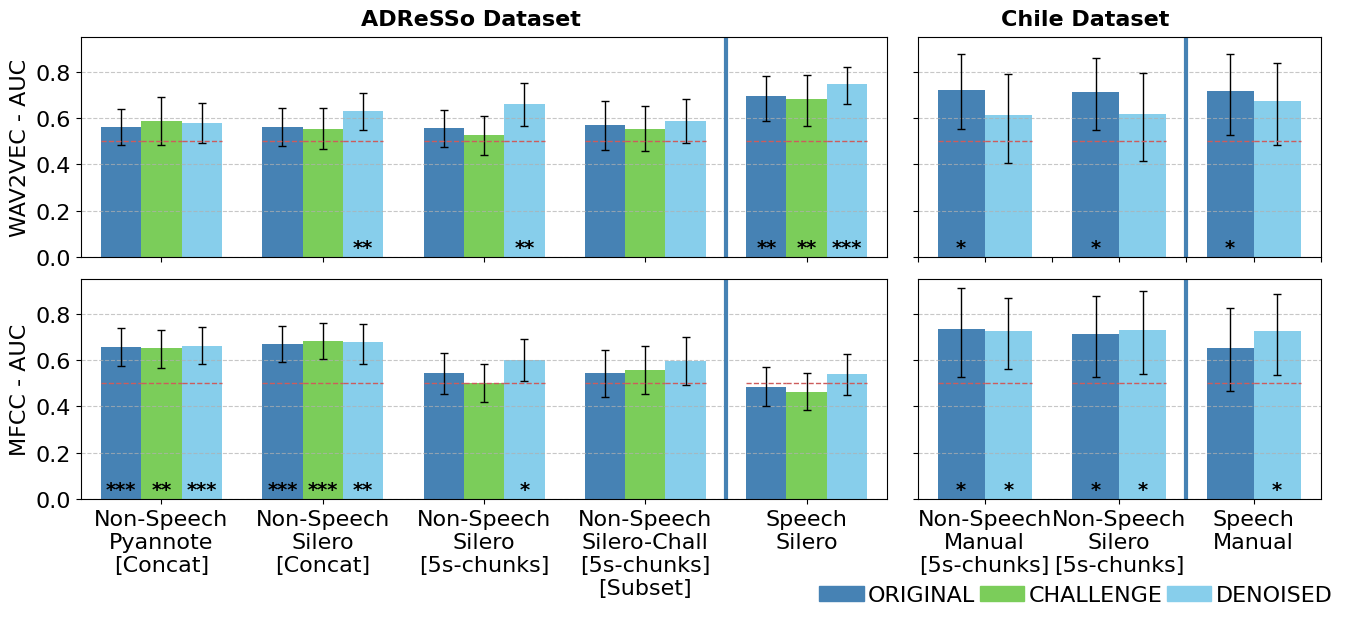

In [ ]:
fig, axes = plt.subplots(nrows=len(feature_order), ncols=2, figsize=(16, 3*len(feature_order)), 
                         sharey=True, gridspec_kw={"wspace": 0.05, "hspace": 0.1, 'width_ratios': [8, 4]}) 

configs = [adresso_nonspeech_conditions, adresso_speech_conditions]
subset_order = ["ORIGINAL", "CHALLENGE", "DENOISED"]
df_to_plot, all_label_order = get_experiments_to_plot(results, configs) 
adresso_axes = axes[:, 0]
plot_experiments_of_dataset(adresso_axes, df_to_plot, all_label_order, feature_order, subset_order, metric, 0.25, sep=3.5)
all_label_order = [label.replace('CHALL', 'Chall').replace('[Chall-woSpeech]', '[Subset]') for label in all_label_order]
adresso_axes[-1].set_xticklabels(all_label_order, rotation=0, ha="center")

handles = [mpatches.Patch(color=colors[s], label=s) for s in subset_order]
fig.legend(handles=handles, frameon=False, bbox_to_anchor=(0.92, 0), ncol=len(subset_order), 
           columnspacing=0.2, handletextpad=0.2,)

configs = [spanishad_nonspeech_conditions, spanishad_only_pat_speech_conditions]
subset_order = ["ORIGINAL", "DENOISED"]
df_to_plot, all_label_order = get_experiments_to_plot(results, configs)
spanishad_axes = axes[:, 1]
plot_experiments_of_dataset(spanishad_axes, df_to_plot, all_label_order, feature_order, subset_order, metric, 0.35, sep=1.5)

axes[0,0].set_ylabel(f"WAV2VEC - {metric.upper()}")
axes[1,0].set_ylabel(f"MFCC - {metric.upper()}")
    
spanishad_axes[-1].set_xticklabels(all_label_order, rotation=0, ha="center")
fig.text(0.3, 0.90,  "ADReSSo Dataset", fontweight="bold", fontsize=16)
fig.text(0.7, 0.90,  "SpanishAD Dataset", fontweight="bold", fontsize=16)
fig.savefig(f"{EXPERIMENT_RESULTS_PATH}/all.pdf", bbox_inches="tight")
fig.tight_layout()


/tmp/ipykernel_2761929/3139633995.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


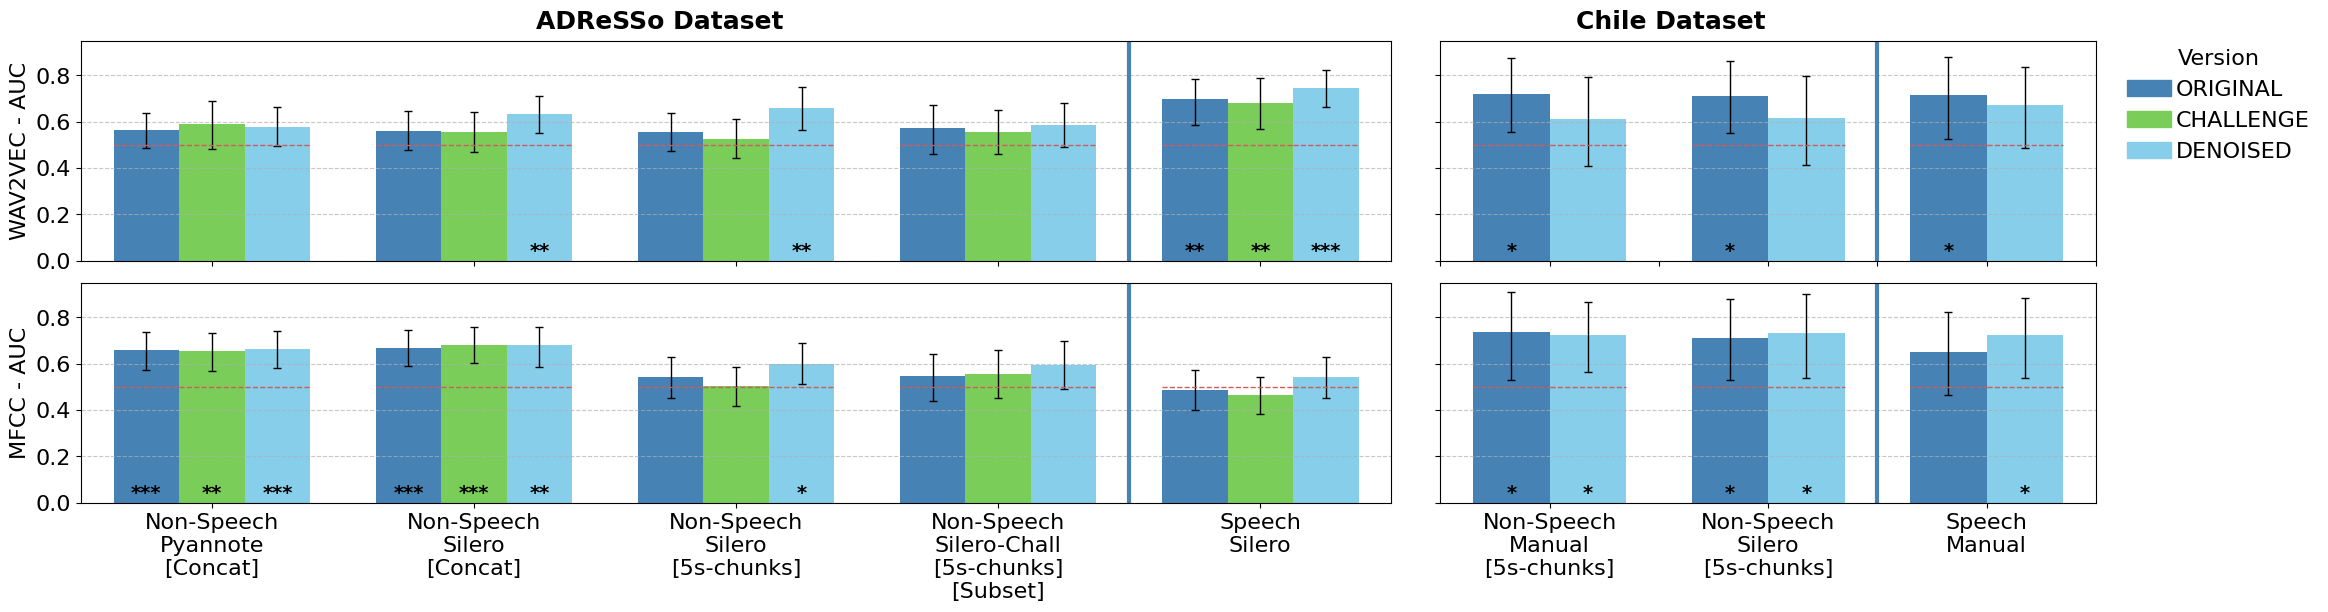

In [ ]:
fig, axes = plt.subplots(nrows=len(feature_order), ncols=2, figsize=(26, 3*len(feature_order)), 
                         sharey=True, gridspec_kw={"wspace": 0.05, "hspace": 0.1, 'width_ratios': [8, 4]}) 

configs = [adresso_nonspeech_conditions, adresso_speech_conditions]
subset_order = ["ORIGINAL", "CHALLENGE", "DENOISED"]
df_to_plot, all_label_order = get_experiments_to_plot(results, configs) 
adresso_axes = axes[:, 0]
plot_experiments_of_dataset(adresso_axes, df_to_plot, all_label_order, feature_order, subset_order, metric, 0.25, sep=3.5)
all_label_order = [label.replace('CHALL', 'Chall').replace('[Chall-woSpeech]', '[Subset]') for label in all_label_order]
adresso_axes[-1].set_xticklabels(all_label_order, rotation=0, ha="center")

handles = [mpatches.Patch(color=colors[s], label=s) for s in subset_order]
fig.legend(handles=handles, bbox_to_anchor=(0.99, 0.9), ncol=1, title="Version", title_fontsize=16, 
           frameon=False, columnspacing=0.2, handletextpad=0.2)

configs = [spanishad_nonspeech_conditions, spanishad_only_pat_speech_conditions]
subset_order = ["ORIGINAL", "DENOISED"]
df_to_plot, all_label_order = get_experiments_to_plot(results, configs)
spanishad_axes = axes[:, 1]
plot_experiments_of_dataset(spanishad_axes, df_to_plot, all_label_order, feature_order, subset_order, metric, 0.35, sep=1.5)

axes[0,0].set_ylabel(f"WAV2VEC - {metric.upper()}")
axes[1,0].set_ylabel(f"MFCC - {metric.upper()}")
    
spanishad_axes[-1].set_xticklabels(all_label_order, rotation=0, ha="center")
fig.text(0.3, 0.90,  "ADReSSo Dataset", fontweight="bold", fontsize=18)
fig.text(0.7, 0.90,  "SpanishAD Dataset", fontweight="bold", fontsize=18)
fig.savefig(f"{EXPERIMENT_RESULTS_PATH}/long-all.pdf", bbox_inches="tight")
fig.tight_layout()


In [ ]:
adresso_nonspeech_conditions = [{
    'dataset':  ['adresso'],
    'aligner':  ['silero-last-t_0.2-sr_16000-non_speech', 'silero-last-t_0.2-sr_16000-dataset_audio-non_speech', 'pyannote-non_speech'],
    'model':    ['AcousticCNNClassifier-group_column_subject-wrap_last_True-batch_size_32-epochs_80-dropout_0.3-projection_dim_128-channel_multiplier_0.5-shuffle-wrap-earlystop-loss-patience_5-minEpochs_1'],
    'filter':  ['', 'silero_with_speech_challenge'], 
    'feature':  ['spectrogram-concatSegs-n_fft_400-hop_length_160-sample_rate_16000',
                 'spectrogram-concatSegs-segSize_5-segOverlap_4-n_fft_400-hop_length_160-sample_rate_16000'],
    'clip':     ['']},
    ['Non-Speech\nPyannote\n[Concat]', 'Non-Speech\nSilero\n[Concat]', 'Non-Speech\nSilero\n[5s-chunks]', 'Non-Speech\nSilero-CHALL\n[5s-chunks]\n[Subset]']
]

adresso_speech_conditions = [{
    'dataset':   ['adresso'],
    'aligner':   ['silero-last-t_0.2-sr_16000'],
    'model':     ['AcousticCNNClassifier-group_column_subject-wrap_last_True-batch_size_32-epochs_80-dropout_0.3-projection_dim_128-channel_multiplier_0.5-shuffle-wrap-earlystop-loss-patience_5-minEpochs_1',],
    'clip':      [''],
    'filter':    [''],
    'feature':   ['spectrogram-n_fft_400-hop_length_160-sample_rate_16000']}, 
    ['Speech\nSilero']
]

spanishad_nonspeech_conditions = [{
    'dataset':   ['spanishad'],
    'aligner':   ['manual-ipu-non_speech', 'silero-last-t_0.2-sr_16000-non_speech', 'pyannote-non_speech'],
    'model':     ['AcousticCNNClassifier-group_column_subject-wrap_last_True-batch_size_32-epochs_80-dropout_0.3-projection_dim_128-channel_multiplier_0.5-shuffle-wrap-earlystop-loss-patience_10-minEpochs_1'],
    'clip':      [''],
    'filter':    [''],
    'feature':   ['spectrogram-concatSegs-n_fft_400-hop_length_160-sample_rate_16000',
                  'spectrogram-concatSegs-segSize_5-segOverlap_4-n_fft_400-hop_length_160-sample_rate_16000']},
    ['Non-Speech\nManual\n[5s-chunks]', 'Non-Speech\nSilero\n[5s-chunks]'],
]

spanishad_only_pat_speech_conditions = [{
    'dataset':   ['spanishad'],
    'aligner':   ['manual-ipu-only_patient'],
    'model':     ['AcousticCNNClassifier-group_column_subject-wrap_last_True-batch_size_32-epochs_80-dropout_0.3-projection_dim_128-channel_multiplier_0.5-shuffle-wrap-earlystop-loss-patience_10-minEpochs_1',],
    'feature':   ['spectrogram-n_fft_400-hop_length_160-sample_rate_16000'],
    'clip':      [''],
    'filter':    [''],}, 
    ['Speech\nManual']
]

feature_order = ["SPECTROGRAM"]
metric = 'auc'


/tmp/ipykernel_2761929/138799034.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


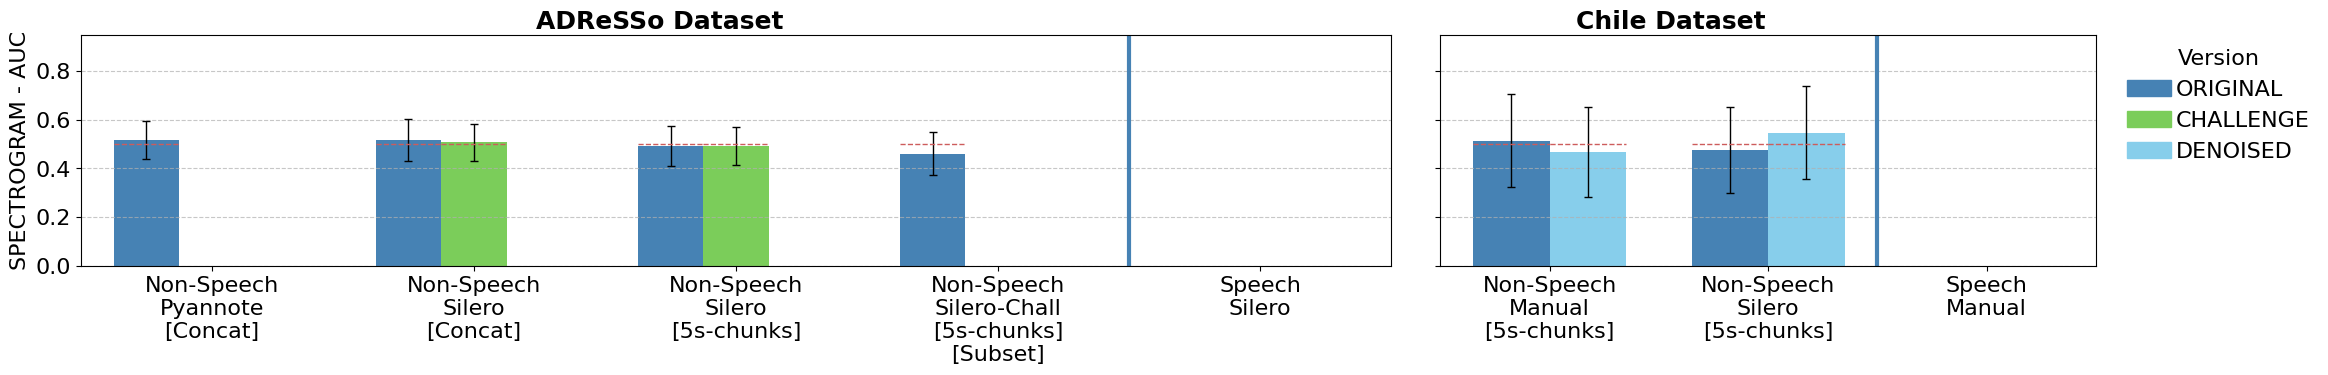

In [ ]:
fig, axes = plt.subplots(nrows=len(feature_order), ncols=2, figsize=(26, 3*len(feature_order)), 
                         sharey=True, gridspec_kw={"wspace": 0.05, "hspace": 0.1, 'width_ratios': [8, 4]}) 

configs = [adresso_nonspeech_conditions, adresso_speech_conditions]
subset_order = ["ORIGINAL", "CHALLENGE", "DENOISED"]
df_to_plot, all_label_order = get_experiments_to_plot(results, configs) 
adresso_axes = axes[0]
plot_experiments_of_dataset(adresso_axes, df_to_plot, all_label_order, feature_order, subset_order, metric, 0.25, sep=3.5)
all_label_order = [label.replace('CHALL', 'Chall').replace('[Chall-woSpeech]', '[Subset]') for label in all_label_order]
adresso_axes.set_xticklabels(all_label_order, rotation=0, ha="center")

handles = [mpatches.Patch(color=colors[s], label=s) for s in subset_order]
fig.legend(handles=handles, bbox_to_anchor=(0.99, 0.9), ncol=1, title="Version", title_fontsize=16, 
           frameon=False, columnspacing=0.2, handletextpad=0.2)

configs = [spanishad_nonspeech_conditions, spanishad_only_pat_speech_conditions]
subset_order = ["ORIGINAL", "DENOISED"]
df_to_plot, all_label_order = get_experiments_to_plot(results, configs)
spanishad_axes = axes[1]
plot_experiments_of_dataset(spanishad_axes, df_to_plot, all_label_order, feature_order, subset_order, metric, 0.35, sep=1.5)

axes[0].set_ylabel(f"SPECTROGRAM - {metric.upper()}")
    
spanishad_axes.set_xticklabels(all_label_order, rotation=0, ha="center")
fig.text(0.3, 0.90,  "ADReSSo Dataset", fontweight="bold", fontsize=18)
fig.text(0.7, 0.90,  "SpanishAD Dataset", fontweight="bold", fontsize=18)
fig.savefig(f"{EXPERIMENT_RESULTS_PATH}/long-all.pdf", bbox_inches="tight")
fig.tight_layout()
